# Pareto Front

In [8]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau")
RESULTS_DIR = PROJECT_ROOT / "results"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from infra_data.scenarios import SCENARIOS

METRICS = ["nominal", "operational", "cost"]

print(f"Expected scenarios: {len(SCENARIOS)}")
print(f"Results directory: {RESULTS_DIR}")

Expected scenarios: 14
Results directory: C:\Users\LeoC\VSCodes\optimizationVinschgau\AusbauVinschgau\results


In [9]:
rows = []
missing = []
invalid = []

for scenario in (s for s in SCENARIOS if s not in ["0", "2a", "all"]):

    path = RESULTS_DIR / scenario / f"{scenario}_results.npy"

    if not path.exists():
        missing.append((scenario, path))
        continue

    try:
        data = np.load(path, allow_pickle=True).item()

        if not isinstance(data, dict):
            raise TypeError("file does not contain a dictionary")

        missing_metrics = [m for m in METRICS if m not in data]
        extra_metrics = [k for k in data if k not in METRICS]

        if missing_metrics:
            raise ValueError(f"missing metrics: {missing_metrics}")

        if extra_metrics:
            raise ValueError(f"unexpected keys: {extra_metrics}")

        values = {m: float(data[m]) for m in METRICS}

        if not all(np.isfinite(v) for v in values.values()):
            raise ValueError("one or more values are not finite")

        rows.append({"scenario": scenario, **values})

    except Exception as e:
        invalid.append((scenario, path, str(e)))

In [10]:
print("=" * 70)
print("SCENARIO RESULTS")
print("=" * 70)

print(f"Expected : {len(SCENARIOS)}")
print(f"Loaded   : {len(rows)}")
print(f"Missing  : {len(missing)}")
print(f"Invalid  : {len(invalid)}")

if missing:
    print("\nMISSING:")
    for scenario, path in missing:
        print(f"  {scenario}: {path}")

if invalid:
    print("\nINVALID:")
    for scenario, path, error in invalid:
        print(f"  {scenario}: {path}")
        print(f"      {error}")

if not missing and not invalid:
    print("\nAll scenario results loaded successfully.")

df = pd.DataFrame(rows).set_index("scenario").sort_index()

display(df)

SCENARIO RESULTS
Expected : 14
Loaded   : 11
Missing  : 0
Invalid  : 0

All scenario results loaded successfully.


,nominal,operational,cost
scenario,,,
1a,47.261512,0.929657,75.483
1b,44.730061,0.926963,75.905
1c,45.841144,0.976122,77.004
3a,45.966667,0.952738,74.707
3b,47.671447,0.948265,76.796
3c,46.000198,0.954641,78.391
3d,48.662474,0.967431,89.771
3e,46.957932,0.948811,87.218
3ee,48.028618,0.978951,93.234


In [11]:
def pareto_mask(df, columns):
    X = df[columns].to_numpy(dtype=float)
    mask = np.ones(len(X), dtype=bool)

    for i in range(len(X)):
        dominated = (
            np.all(X <= X[i], axis=1)
            & np.any(X < X[i], axis=1)
        )
        dominated[i] = False
        mask[i] = not dominated.any()

    return mask


df["pareto"] = pareto_mask(df, METRICS)

pareto_df = df[df["pareto"]].copy()
dominated_df = df[~df["pareto"]].copy()

print(f"Pareto-optimal scenarios: {len(pareto_df)} / {len(df)}")

display(pareto_df.sort_values(METRICS))

Pareto-optimal scenarios: 3 / 11


,nominal,operational,cost,pareto
scenario,,,,
1b,44.730061,0.926963,75.905,True
3a,45.966667,0.952738,74.707,True
1a,47.261512,0.929657,75.483,True


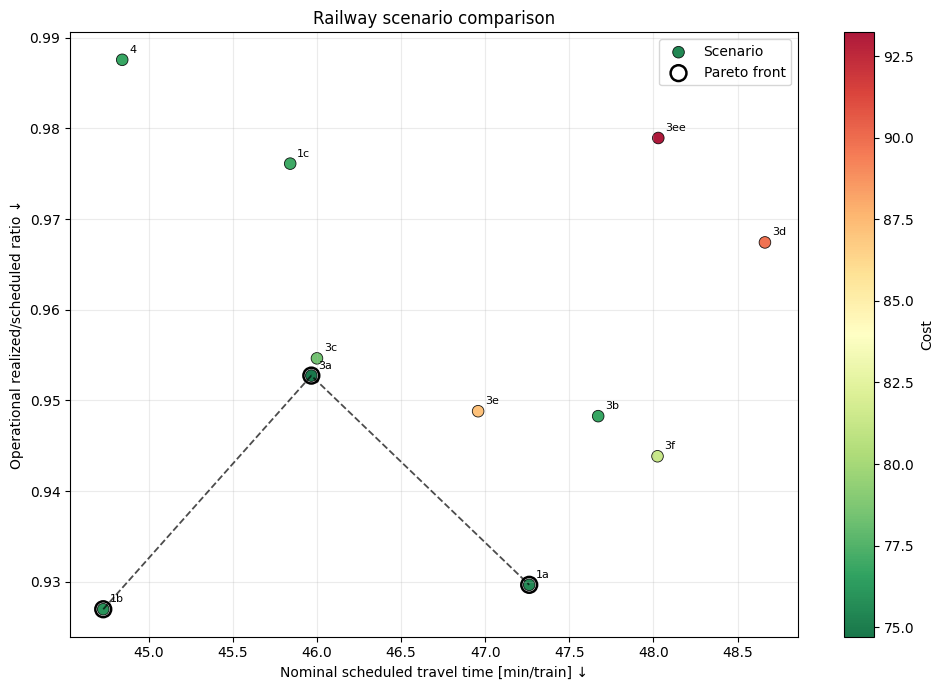

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

cost_min = df["cost"].min()
cost_max = df["cost"].max()

if cost_min == cost_max:
    norm = plt.Normalize(cost_min - 1, cost_max + 1)
else:
    norm = plt.Normalize(cost_min, cost_max)

scatter = ax.scatter(
    df["nominal"],
    df["operational"],
    c=df["cost"],
    cmap="RdYlGn_r",
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    label="Scenario",
)

for scenario, row in df.iterrows():
    ax.annotate(
        scenario,
        (row["nominal"], row["operational"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

pareto_plot = pareto_df.sort_values("nominal")

ax.scatter(
    pareto_plot["nominal"],
    pareto_plot["operational"],
    s=130,
    facecolors="none",
    edgecolors="black",
    linewidth=1.8,
    label="Pareto front",
    zorder=4,
)

if len(pareto_plot) >= 2:
    ax.plot(
        pareto_plot["nominal"],
        pareto_plot["operational"],
        linestyle="--",
        linewidth=1.3,
        color="black",
        alpha=0.7,
        zorder=3,
    )

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Cost")

ax.set_xlabel("Nominal scheduled travel time [min/train] ↓")
ax.set_ylabel("Operational realized/scheduled ratio ↓")
ax.set_title("Railway scenario comparison")
ax.grid(alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

Hyperbolic fit: operational = -2.3115 / nominal + 0.986744


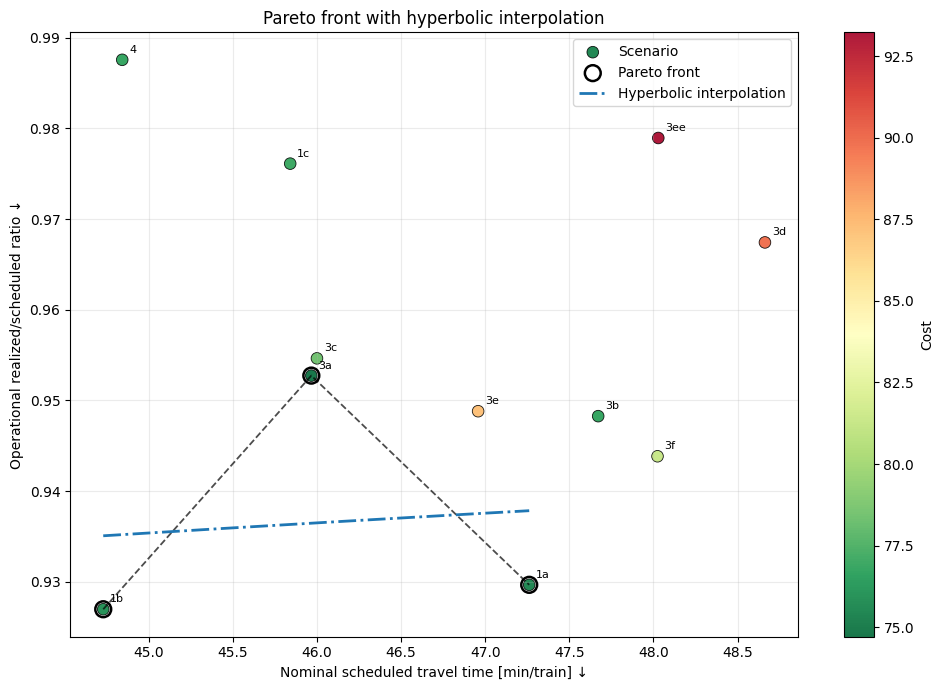

In [13]:
def fit_hyperbola(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x != 0)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 or np.allclose(x, x[0]):
        return None

    A = np.column_stack((1 / x, np.ones_like(x)))
    a, b = np.linalg.lstsq(A, y, rcond=None)[0]

    return float(a), float(b)


x = pareto_plot["nominal"].to_numpy()
y = pareto_plot["operational"].to_numpy()

params = fit_hyperbola(x, y)

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df["nominal"],
    df["operational"],
    c=df["cost"],
    cmap="RdYlGn_r",
    norm=norm,
    s=70,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.9,
    label="Scenario",
)

for scenario, row in df.iterrows():
    ax.annotate(
        scenario,
        (row["nominal"], row["operational"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.scatter(
    pareto_plot["nominal"],
    pareto_plot["operational"],
    s=130,
    facecolors="none",
    edgecolors="black",
    linewidth=1.8,
    label="Pareto front",
    zorder=4,
)

if len(pareto_plot) >= 2:
    ax.plot(
        x,
        y,
        linestyle="--",
        linewidth=1.3,
        color="black",
        alpha=0.7,
    )

if params is not None:
    a, b = params

    x_curve = np.linspace(x.min(), x.max(), 300)
    y_curve = a / x_curve + b

    ax.plot(
        x_curve,
        y_curve,
        linestyle="-.",
        linewidth=2,
        label="Hyperbolic interpolation",
    )

    print(f"Hyperbolic fit: operational = {a:.6g} / nominal + {b:.6g}")
else:
    print("Hyperbolic interpolation not possible with the available Pareto points.")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Cost")

ax.set_xlabel("Nominal scheduled travel time [min/train] ↓")
ax.set_ylabel("Operational realized/scheduled ratio ↓")
ax.set_title("Pareto front with hyperbolic interpolation")
ax.grid(alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [14]:
def topsis(df, criteria, weights=None):
    X = df[criteria].to_numpy(dtype=float)

    if weights is None:
        weights = np.ones(len(criteria)) / len(criteria)
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / weights.sum()

    # Vector normalization
    denominator = np.sqrt((X ** 2).sum(axis=0))

    if np.any(denominator == 0):
        raise ValueError("TOPSIS cannot normalize a criterion with zero norm.")

    normalized = X / denominator

    # Apply weights
    weighted = normalized * weights

    # All criteria are minimization criteria
    ideal_best = weighted.min(axis=0)
    ideal_worst = weighted.max(axis=0)

    # Distance from ideal best and ideal worst
    distance_best = np.sqrt(
        ((weighted - ideal_best) ** 2).sum(axis=1)
    )

    distance_worst = np.sqrt(
        ((weighted - ideal_worst) ** 2).sum(axis=1)
    )

    # TOPSIS closeness coefficient
    denominator = distance_best + distance_worst

    score = np.divide(
        distance_worst,
        denominator,
        out=np.zeros_like(distance_worst),
        where=denominator != 0,
    )

    result = df.copy()
    result["topsis_score"] = score
    result["topsis_rank"] = (
        result["topsis_score"]
        .rank(ascending=False, method="min")
        .astype(int)
    )

    return result.sort_values(
        ["topsis_rank", "scenario"]
    )

In [15]:
topsis_df = topsis(
    pareto_df,
    METRICS,
    weights=[1/3, 1/3, 1/3],
)

display(
    topsis_df[
        ["nominal", "operational", "cost", "topsis_score", "topsis_rank"]
    ]
)

,nominal,operational,cost,topsis_score,topsis_rank
scenario,,,,,
1b,44.730061,0.926963,75.905,0.794705,1
3a,45.966667,0.952738,74.707,0.456600,2
1a,47.261512,0.929657,75.483,0.310725,3


In [16]:
best_scenario = topsis_df["topsis_score"].idxmax()
best = topsis_df.loc[best_scenario]

print("=" * 60)
print("TOPSIS RESULT")
print("=" * 60)
print(f"Best scenario : {best_scenario}")
print(f"Nominal       : {best['nominal']:.3f}")
print(f"Operational   : {best['operational']:.5f}")
print(f"Cost          : {best['cost']:.2f}")
print(f"TOPSIS score  : {best['topsis_score']:.6f}")

TOPSIS RESULT
Best scenario : 1b
Nominal       : 44.730
Operational   : 0.92696
Cost          : 75.91
TOPSIS score  : 0.794705
